# PART 7

Haikal Ali_1103223071_TK46GAB

# Chapter 7 - Unsupervised Learning

Catatan: beberapa kode menggunakan variabel data yang memang disebut di materi, seperti `sp500_px`, `loan_data`, `defaults`, dan `housetasks`. PDF tidak menyediakan file datasetnya, jadi cell tersebut membutuhkan data tersebut agar bisa dijalankan.

## 1. Pengantar Unsupervised Learning

**Unsupervised learning** adalah metode statistik untuk mengambil makna dari data tanpa label target. Berbeda dengan supervised learning yang memisahkan variabel respons dan prediktor, unsupervised learning membangun pemahaman dari struktur data itu sendiri.

Kegunaannya dalam materi ini:

- menemukan kelompok data menggunakan clustering,
- mengurangi dimensi data menjadi fitur yang lebih sedikit,
- membantu exploratory data analysis ketika jumlah variabel dan record besar.

Unsupervised learning juga dapat membantu prediksi saat label belum tersedia, misalnya pada cold-start problem. Clustering bisa dipakai untuk mengidentifikasi segmen awal sebelum model prediktif yang lebih lengkap dibuat.

## 2. Principal Components Analysis (PCA)

PCA digunakan untuk menemukan bagaimana variabel numerik saling berubah bersama. PCA membentuk variabel baru bernama **principal components**, yaitu kombinasi linear dari variabel awal.

Istilah penting:

- **Principal component**: kombinasi linear dari variabel prediktor.
- **Loadings**: bobot yang mengubah variabel awal menjadi komponen.
- **Screeplot**: plot variansi komponen untuk melihat pentingnya tiap komponen.

Tujuan PCA adalah mereduksi dimensi data dengan tetap mempertahankan sebagian besar variasi data.

### 2.1 Contoh Sederhana PCA

Untuk dua variabel, `X1` dan `X2`, principal component dapat ditulis sebagai:

`Zi = wi,1 X1 + wi,2 X2`

Bobot `wi,1` dan `wi,2` disebut **component loadings**. Komponen pertama menjelaskan variasi terbesar. Komponen kedua dibuat ortogonal terhadap komponen pertama dan menjelaskan variasi sisanya.

In [2]:
from sklearn.decomposition import PCA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
pcs = PCA(n_components=2)
pcs.fit(oil_px)
loadings = pd.DataFrame(pcs.components_, columns=oil_px.columns)
loadings

ValueError: could not convert string to float: '1993-01-29'

Contoh pada materi memakai return saham Chevron (`CVX`) dan ExxonMobil (`XOM`). Komponen pertama pada dasarnya menangkap gerakan bersama kedua saham energi tersebut, sedangkan komponen kedua menangkap perbedaan gerak antara keduanya.

In [ ]:
def abline(slope, intercept, ax):
  """Calculate coordinates of a line based on slope and intercept"""
  x_vals = np.array(ax.get_xlim())
  return (x_vals, intercept + slope * x_vals)

ax = oil_px.plot.scatter(x='XOM', y='CVX', alpha=0.3, figsize=(4, 4))
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
ax.plot(*abline(loadings.loc[0, 'CVX'] / loadings.loc[0, 'XOM'], 0, ax),
        '--', color='C1')
ax.plot(*abline(loadings.loc[1, 'CVX'] / loadings.loc[1, 'XOM'], 0, ax),
        '--', color='C1')

Tanda positif atau negatif pada loading PCA dapat dibalik tanpa mengubah makna principal component. Arah garis yang sama tetap merepresentasikan komponen yang sama.

### 2.2 Menghitung Principal Components

Proses PCA menurut materi:

1. PCA mencari kombinasi linear yang menjelaskan persentase variansi terbesar.
2. Kombinasi tersebut menjadi komponen pertama, `Z1`.
3. PCA mengulang proses untuk membuat `Z2`, dengan syarat tidak berkorelasi dengan `Z1`.
4. Proses berlanjut sampai jumlah komponen sama dengan jumlah variabel awal.
5. Pilih jumlah komponen yang cukup untuk menjelaskan sebagian besar variansi.
6. Data awal dikonversi menjadi skor principal component menggunakan bobot yang sudah diperoleh.

PCA hanya bekerja untuk variabel numerik, bukan variabel kategorikal.

### 2.3 Interpretasi Principal Components

Screeplot digunakan untuk melihat seberapa besar variansi yang dijelaskan oleh komponen-komponen utama.

In [11]:
sp500_px = pd.read_csv('/content/sp500_data.csv')

Text(0.5, 0, 'Component')

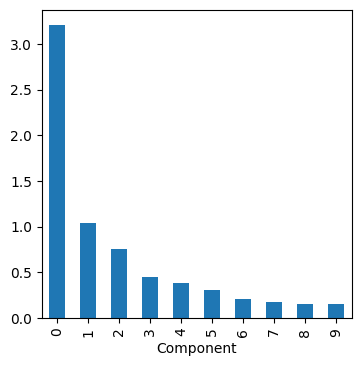

In [14]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px['Unnamed: 0'] >= '2011-01-01', syms]
sp_pca = PCA()
sp_pca.fit(top_sp)
explained_variance = pd.DataFrame(sp_pca.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

Selain screeplot, loading dari komponen utama juga dapat diplot untuk melihat kontribusi masing-masing variabel terhadap tiap komponen.

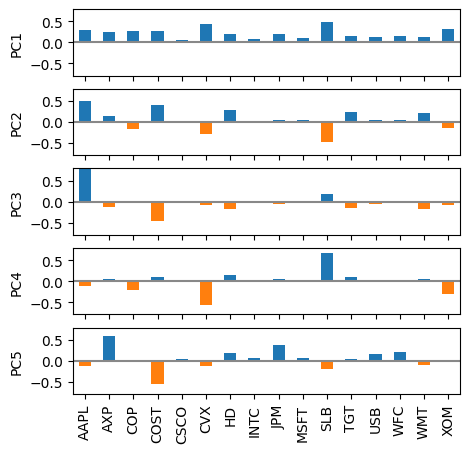

In [15]:
loadings = pd.DataFrame(sp_pca.components_[0:5, :], columns=top_sp.columns)
maxPC = 1.01 * np.max(np.max(np.abs(loadings.loc[0:5, :])))
f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)
for i, ax in enumerate(axes):
  pc_loadings = loadings.loc[i, :]
  colors = ['C0' if l > 0 else 'C1' for l in pc_loadings]
  ax.axhline(color='#888888')
  pc_loadings.plot.bar(ax=ax, color=colors)
  ax.set_ylabel(f'PC{i+1}')
  ax.set_ylim(-maxPC, maxPC)

Pada contoh saham, loading komponen pertama memiliki tanda yang sama karena semua saham berbagi faktor umum, yaitu tren pasar saham. Komponen berikutnya menangkap perbedaan gerak antar kelompok saham.

### 2.4 Memilih Jumlah Komponen

Jumlah komponen dipilih sesuai tujuan reduksi dimensi. Cara umum:

- melihat screeplot,
- memilih komponen sampai cumulative variance melewati ambang tertentu, misalnya 80%,
- memeriksa apakah loading komponen memiliki interpretasi yang masuk akal,
- menggunakan cross-validation untuk cara yang lebih formal.

### 2.5 Correspondence Analysis

PCA tidak dapat digunakan untuk data kategorikal. Teknik yang mirip untuk kategori adalah **correspondence analysis**. Tujuannya mengenali asosiasi antara kategori.

Inputnya berupa tabel hitungan, dengan baris sebagai satu variabel, kolom sebagai variabel lain, dan isi tabel sebagai jumlah record. Outputnya dapat berupa biplot yang menampilkan kedekatan antar kategori.

In [16]:
pip install prince

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 197.3/197.3 kB 5.3 MB/s eta 0:00:00


In [19]:
import prince

In [24]:
housetask = pd.read_csv('/content/housetasks.csv')

In [25]:
housetasks = housetask.select_dtypes(include=['int', 'int64'])

In [26]:
ca = prince.CA(n_components=2)
ca = ca.fit(housetasks)
ca.plot_coordinates(housetasks, figsize=(6, 6))

AttributeError: 'CA' object has no attribute 'plot_coordinates'

Inti PCA menurut materi:

- principal components adalah kombinasi linear dari variabel prediktor numerik,
- komponen dibuat agar korelasi antar komponen kecil,
- beberapa komponen biasanya cukup untuk menjelaskan sebagian besar variansi,
- correspondence analysis mirip secara ide untuk data kategorikal, tetapi tidak dipakai dengan cara yang sama seperti PCA untuk reduksi dimensi big data.

## 3. K-Means Clustering

Clustering membagi data menjadi beberapa kelompok. Record dalam kelompok yang sama dibuat semirip mungkin. K-means membagi data menjadi `K` cluster dengan meminimalkan jumlah kuadrat jarak setiap record terhadap rata-rata cluster-nya.

Istilah penting:

- **Cluster**: kelompok record yang mirip.
- **Cluster mean**: vektor rata-rata variabel dalam cluster.
- **K**: jumlah cluster.

Variabel kontinu umumnya perlu dinormalisasi. Jika tidak, variabel dengan skala besar akan mendominasi proses clustering.

### 3.1 Contoh K-Means

Materi menggunakan return harian saham ExxonMobil (`XOM`) dan Chevron (`CVX`) dan membaginya menjadi 4 cluster.

In [28]:
from sklearn.cluster import KMeans

df = sp500_px.loc[sp500_px['Unnamed: 0'] >= '2011-01-01', ['XOM', 'CVX']]
kmeans = KMeans(n_clusters=4).fit(df)

In [29]:
df['cluster'] = kmeans.labels_
df.head()

,XOM,CVX,cluster
4516,0.736805,0.240681,3
4517,0.168668,-0.584516,1
4518,0.026631,0.446985,3
4519,0.248558,-0.919751,1
4520,0.337329,0.180511,3


In [30]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=['XOM', 'CVX'])
centers

,XOM,CVX
0,0.927032,1.346412
1,-0.330814,-0.574398
2,-1.144397,-1.757796
3,0.231540,0.316965


Cluster dengan nilai rata-rata negatif merepresentasikan kondisi pasar turun, sedangkan cluster dengan nilai rata-rata positif merepresentasikan kondisi pasar naik.

<Axes: xlabel='XOM', ylabel='CVX'>

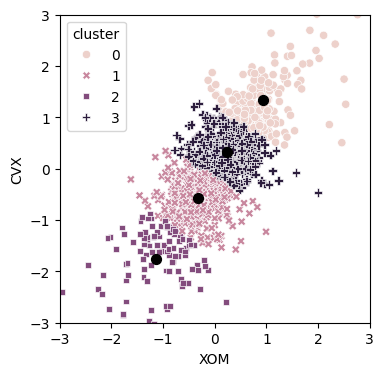

In [31]:
fig, ax = plt.subplots(figsize=(4, 4))
ax = sns.scatterplot(x='XOM', y='CVX', hue='cluster', style='cluster',
                     ax=ax, data=df)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)
centers.plot.scatter(x='XOM', y='CVX', ax=ax, s=50, color='black')

### 3.2 Algoritma K-Means

Langkah dasar K-means:

1. Tentukan jumlah cluster `K` dan mean awal cluster.
2. Assign setiap record ke cluster mean terdekat berdasarkan squared distance.
3. Hitung ulang cluster mean berdasarkan assignment terbaru.
4. Ulangi sampai assignment record tidak berubah.

Karena titik awal bersifat acak, algoritma sebaiknya dijalankan beberapa kali dengan random start berbeda. Hasil yang dipilih adalah yang memiliki within-cluster sum of squares paling kecil.

In [33]:
syms = sorted(['AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM', 'SLB', 'COP',
               'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST'])
top_sp = sp500_px.loc[sp500_px['Unnamed: 0'] >= '2011-01-01', syms]
kmeans = KMeans(n_clusters=5).fit(top_sp)

### 3.3 Interpretasi Cluster

Dua output penting dari K-means adalah ukuran cluster dan cluster mean. Cluster yang sangat tidak seimbang dapat menunjukkan outlier jauh atau kelompok record yang sangat berbeda dari data lain.

In [34]:
from collections import Counter

Counter(kmeans.labels_)

Counter({np.int32(1): 305,
         np.int32(4): 275,
         np.int32(0): 288,
         np.int32(2): 152,
         np.int32(3): 111})

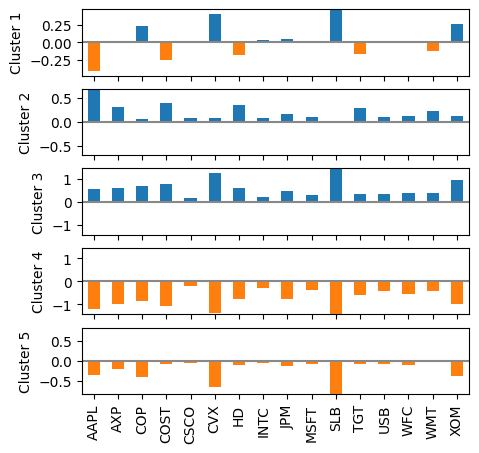

In [35]:
centers = pd.DataFrame(kmeans.cluster_centers_, columns=syms)
f, axes = plt.subplots(5, 1, figsize=(5, 5), sharex=True)
for i, ax in enumerate(axes):
  center = centers.loc[i, :]
  maxPC = 1.01 * np.max(np.max(np.abs(center)))
  colors = ['C0' if l > 0 else 'C1' for l in center]
  ax.axhline(color='#888888')
  center.plot.bar(ax=ax, color=colors)
  ax.set_ylabel(f'Cluster {i + 1}')
  ax.set_ylim(-maxPC, maxPC)

Plot cluster mean mirip dengan plot loading PCA, tetapi maknanya berbeda. Pada PCA, tanda loading dapat dibalik tanpa mengubah komponen. Pada clustering, tanda cluster mean tetap bermakna karena menunjukkan lokasi kelompok record.

### 3.4 Memilih Jumlah Cluster

K-means mengharuskan pengguna menentukan `K`. Kadang `K` ditentukan oleh kebutuhan praktis, misalnya jumlah persona pelanggan yang ingin dibuat.

Jika tidak ada kebutuhan praktis, metode yang umum adalah **elbow method**. Prinsipnya mencari titik ketika penambahan cluster hanya memberi sedikit tambahan penjelasan variasi. Tidak selalu ada elbow yang jelas, terutama pada data yang cluster-nya tidak terpisah kuat.

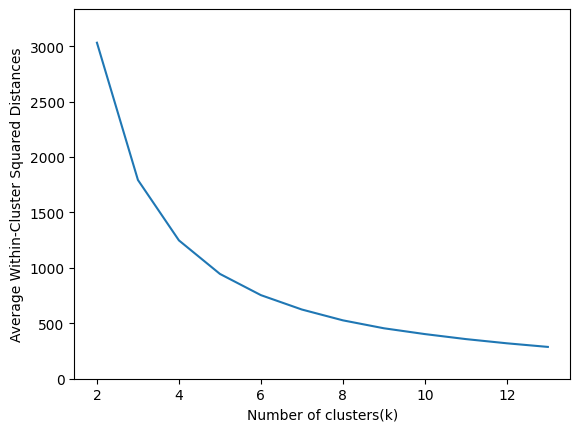

In [36]:
inertia = []
for n_clusters in range(2, 14):
  kmeans = KMeans(n_clusters=n_clusters, random_state=0).fit(top_sp)
  inertia.append(kmeans.inertia_ / n_clusters)

inertias = pd.DataFrame({'n_clusters': range(2, 14), 'inertia': inertia})
ax = inertias.plot(x='n_clusters', y='inertia')
plt.xlabel('Number of clusters(k)')
plt.ylabel('Average Within-Cluster Squared Distances')
plt.ylim((0, 1.1 * inertias.inertia.max()))
ax.legend().set_visible(False)

Inti K-means menurut materi:

- jumlah cluster `K` dipilih oleh pengguna,
- algoritma mengembangkan cluster dengan assignment iteratif ke mean terdekat,
- pertimbangan praktis sering lebih penting daripada aturan statistik dalam memilih `K`,
- tidak ada satu aturan statistik yang selalu benar untuk menentukan jumlah cluster optimal.

## 4. Hierarchical Clustering

Hierarchical clustering adalah alternatif K-means yang dapat menghasilkan cluster berbeda. Keunggulannya adalah struktur cluster dapat divisualisasikan melalui dendrogram, sehingga pengguna bisa melihat efek dari pemilihan jumlah cluster berbeda.

Istilah penting:

- **Dendrogram**: visualisasi record dan hierarki cluster.
- **Distance**: ukuran kedekatan antar record.
- **Dissimilarity**: ukuran perbedaan antar cluster.

Metode ini lebih sensitif untuk menemukan kelompok atau record outlier, tetapi kurang cocok untuk data sangat besar karena kebutuhan komputasinya tinggi.

### 4.1 Contoh Hierarchical Clustering

Materi melakukan clustering terhadap perusahaan, bukan tanggal. Karena algoritma clustering mengelompokkan baris, data saham perlu ditranspose agar perusahaan berada pada baris.

In [39]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

syms1 = ['AAPL', 'AMZN', 'AXP', 'COP', 'COST', 'CSCO', 'CVX', 'GOOGL', 'HD',
         'INTC', 'JPM', 'MSFT', 'SLB', 'TGT', 'USB', 'WFC', 'WMT', 'XOM']
df = sp500_px.loc[sp500_px['Unnamed: 0'] >= '2011-01-01', syms1].transpose()
Z = linkage(df, method='complete')

### 4.2 Dendrogram

Dendrogram menampilkan struktur hierarki cluster sebagai pohon. Panjang cabang menunjukkan tingkat ketidakmiripan antar cluster.

Text(0, 0.5, 'distance')

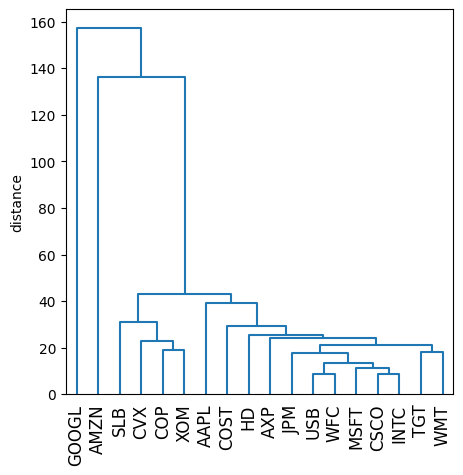

In [40]:
fig, ax = plt.subplots(figsize=(5, 5))
dendrogram(Z, labels=df.index, ax=ax, color_threshold=0)
plt.xticks(rotation=90)
ax.set_ylabel('distance')

In [41]:
memb = fcluster(Z, 4, criterion='maxclust')
memb = pd.Series(memb, index=df.index)
for key, item in memb.groupby(memb):
  print(f"{key} : {', '.join(item.index)}")

1 : COP, CVX, SLB, XOM
2 : AAPL, AXP, COST, CSCO, HD, INTC, JPM, MSFT, TGT, USB, WFC, WMT
3 : AMZN
4 : GOOGL


### 4.3 Algoritma Agglomerative

Hierarchical clustering biasanya memakai algoritma agglomerative:

1. Awalnya setiap record menjadi satu cluster sendiri.
2. Hitung dissimilarity untuk semua pasangan cluster.
3. Gabungkan dua cluster yang paling mirip.
4. Ulangi sampai seluruh record menjadi satu cluster besar.

Jarak antar record dapat dihitung dengan Euclidean distance. Jarak antar cluster dapat dihitung dengan beberapa ukuran dissimilarity.

### 4.4 Ukuran Dissimilarity

Materi menyebut empat ukuran umum:

- **Complete linkage**: memakai jarak maksimum antar pasangan record dari dua cluster.
- **Single linkage**: memakai jarak minimum antar pasangan record.
- **Average linkage**: memakai rata-rata semua jarak pasangan record.
- **Minimum variance / Ward's method**: mirip K-means karena meminimalkan within-cluster sum of squares.

Hasil hierarchical clustering dapat sangat berbeda tergantung ukuran dissimilarity yang dipilih.

Inti hierarchical clustering menurut materi:

- dimulai dari setiap record sebagai cluster sendiri,
- cluster digabung secara bertahap sampai semua record masuk satu cluster,
- riwayat penggabungan dapat diplot dalam dendrogram,
- jarak antar cluster dapat dihitung dengan beberapa cara.

## 5. Model-Based Clustering

K-means dan hierarchical clustering berbasis heuristik. Model-based clustering menggunakan model probabilitas untuk menjelaskan asal cluster. Setiap cluster diasumsikan berasal dari proses data-generating yang berbeda.

Metode ini lebih kuat secara teori, tetapi lebih berat secara komputasi dan sangat bergantung pada asumsi model.

### 5.1 Multivariate Normal Distribution

Model-based clustering yang umum memakai **multivariate normal distribution**. Distribusi ini memperluas normal distribution untuk beberapa variabel sekaligus. Distribusi dijelaskan oleh:

- vektor mean `μ`,
- covariance matrix `Σ`.

Covariance matrix menunjukkan bagaimana variabel saling berkorelasi.

### 5.2 Mixtures of Normals

Ide utamanya: setiap record diasumsikan berasal dari salah satu dari `K` distribusi normal multivariat. Setiap distribusi memiliki mean dan covariance matrix berbeda.

In [43]:
from sklearn.mixture import GaussianMixture

df = sp500_px.loc[sp500_px['Unnamed: 0'] >= '2011-01-01', ['XOM', 'CVX']]
mclust = GaussianMixture(n_components=2).fit(df)
mclust.bic(df)

np.float64(4589.3203170532615)

(-3.0, 3.0)

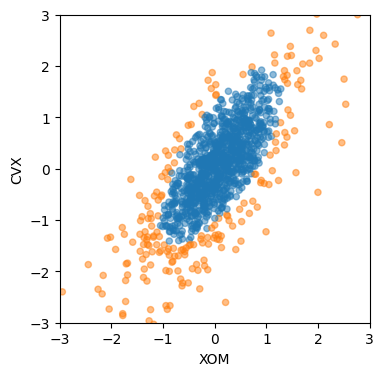

In [44]:
fig, ax = plt.subplots(figsize=(4, 4))
colors = [f'C{c}' for c in mclust.predict(df)]
df.plot.scatter(x='XOM', y='CVX', c=colors, alpha=0.5, ax=ax)
ax.set_xlim(-3, 3)
ax.set_ylim(-3, 3)

In [45]:
print('Mean')
print(mclust.means_)
print('Covariances')
print(mclust.covariances_)

Mean
[[ 0.0709161   0.10228006]
 [-0.05074943 -0.21539465]]
Covariances
[[[0.27074158 0.27800893]
  [0.27800893 0.5212865 ]]

 [[0.98668327 0.99350046]
  [0.99350046 1.69695919]]]


Pada contoh saham, model-based clustering menghasilkan satu cluster di tengah data dan satu cluster di bagian luar. Ini berbeda dari K-means dan hierarchical clustering yang cenderung mencari cluster yang kompak.

### 5.3 Memilih Jumlah Cluster pada Model-Based Clustering

Pada `mclust` di R, jumlah cluster dipilih otomatis berdasarkan BIC. Di Python, `GaussianMixture` tidak mencoba semua kombinasi secara otomatis, sehingga kombinasi jumlah komponen dan jenis covariance perlu dicoba secara manual.

In [46]:
results = []
covariance_types = ['full', 'tied', 'diag', 'spherical']
for n_components in range(1, 9):
  for covariance_type in covariance_types:
    mclust = GaussianMixture(n_components=n_components, warm_start=True,
                             covariance_type=covariance_type)
    mclust.fit(df)
    results.append({
      'bic': mclust.bic(df),
      'n_components': n_components,
      'covariance_type': covariance_type,
    })

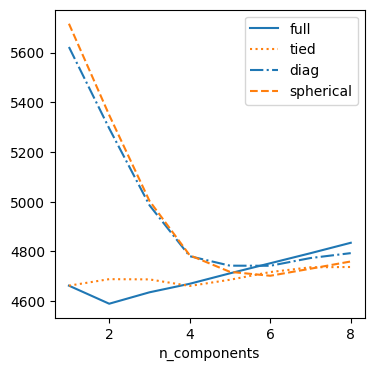

In [47]:
results = pd.DataFrame(results)
colors = ['C0', 'C1', 'C2', 'C3']
styles = ['C0-', 'C1:', 'C0-.', 'C1--']
fig, ax = plt.subplots(figsize=(4, 4))
for i, covariance_type in enumerate(covariance_types):
  subset = results.loc[results.covariance_type == covariance_type, :]
  subset.plot(x='n_components', y='bic', ax=ax, label=covariance_type,
              kind='line', style=styles[i])

Inti model-based clustering menurut materi:

- cluster diasumsikan berasal dari proses data yang berbeda dengan distribusi probabilitas berbeda,
- beberapa model dicoba dengan jumlah distribusi berbeda,
- model dipilih berdasarkan keseimbangan antara kecocokan data dan jumlah parameter agar tidak overfitting.

## 6. Scaling dan Variabel Kategorikal

Teknik unsupervised learning umumnya membutuhkan data yang sudah diskalakan dengan benar. Jika skala variabel berbeda jauh, variabel dengan nilai besar akan mendominasi PCA, K-means, dan clustering lain.

Istilah penting:

- **Scaling**: mengubah skala data agar variabel berada pada skala yang sebanding.
- **Normalization / Standardization**: mengurangi mean lalu membagi dengan standard deviation.
- **Gower's distance**: metode scaling untuk data campuran numerik dan kategorikal agar berada pada rentang 0-1.

### 6.1 Scaling Variabel

Contoh pertama menerapkan K-means pada data loan default tanpa normalisasi.

In [48]:
defaults = loan_data.loc[loan_data['outcome'] == 'default',]
columns = ['loan_amnt', 'annual_inc', 'revol_bal', 'open_acc',
           'dti', 'revol_util']
df = defaults[columns]
kmeans = KMeans(n_clusters=4, random_state=1).fit(df)
counts = Counter(kmeans.labels_)
centers = pd.DataFrame(kmeans.cluster_centers_, columns=columns)
centers['size'] = [counts[i] for i in range(4)]
centers

NameError: name 'loan_data' is not defined

Tanpa scaling, variabel seperti `annual_inc` dan `revol_bal` mendominasi cluster.

Normalisasi z-score dilakukan dengan rumus:

`z = (x - mean) / standard deviation`

In [ ]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1).fit(df0)
counts = Counter(kmeans.labels_)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                       columns=columns)
centers['size'] = [counts[i] for i in range(4)]
centers

Setelah normalisasi, ukuran cluster lebih seimbang dan struktur data lebih mudah dilihat. Cluster center dikembalikan ke skala awal agar lebih mudah diinterpretasikan.

Scaling juga penting untuk PCA. Menggunakan z-score setara dengan memakai correlation matrix daripada covariance matrix.

### 6.2 Dominant Variables

Meskipun variabel berada pada skala yang sama, ada kasus ketika satu atau dua variabel mendominasi PCA. Contohnya ketika `GOOGL` dan `AMZN` ditambahkan ke analisis saham.

Text(0.5, 0, 'Component')

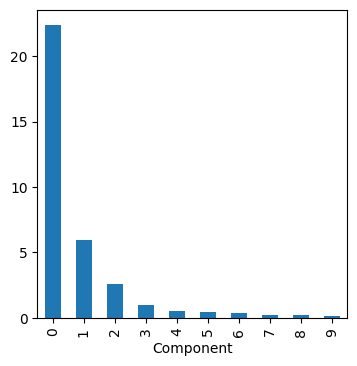

In [49]:
syms = ['GOOGL', 'AMZN', 'AAPL', 'MSFT', 'CSCO', 'INTC', 'CVX', 'XOM',
        'SLB', 'COP', 'JPM', 'WFC', 'USB', 'AXP', 'WMT', 'TGT', 'HD', 'COST']
top_sp1 = sp500_px.loc[sp500_px['Unnamed: 0'] >= '2005-01-01', syms]
sp_pca1 = PCA()
sp_pca1.fit(top_sp1)
explained_variance = pd.DataFrame(sp_pca1.explained_variance_)
ax = explained_variance.head(10).plot.bar(legend=False, figsize=(4, 4))
ax.set_xlabel('Component')

In [50]:
loadings = pd.DataFrame(sp_pca1.components_[0:2, :], columns=top_sp1.columns)
loadings.transpose()

,0,1
GOOGL,0.857310,-0.477873
AMZN,0.444728,0.874149
AAPL,0.071627,0.020802
MSFT,0.036002,0.006204
CSCO,0.029205,0.003045
INTC,0.026666,0.006069
CVX,0.089548,0.037420
XOM,0.080336,0.020511
SLB,0.110218,0.030356
COP,0.057739,0.024117


Jika variabel dominan muncul, pilihan yang disebut materi adalah membiarkannya, melakukan rescaling, atau mengeluarkan variabel dominan dari analisis dan menanganinya secara terpisah. Tidak ada satu pendekatan yang selalu benar; pilihan bergantung pada aplikasi.

### 6.3 Data Kategorikal dan Gower's Distance

Untuk data kategorikal, data perlu diubah menjadi numerik, misalnya dengan ranking untuk ordered factor atau dummy variables untuk kategori biasa. Jika data mencampur variabel kontinu dan biner, skala variabel perlu diseimbangkan.

Gower's distance bekerja dengan ide berikut:

1. Untuk variabel numerik dan ordered factor, jarak dihitung sebagai nilai absolut perbedaan dua record.
2. Untuk variabel kategorikal, jarak bernilai 1 jika kategorinya berbeda dan 0 jika sama.
3. Semua jarak pasangan diskalakan ke rentang 0-1.
4. Jarak antar variabel dijumlahkan memakai mean sederhana atau berbobot untuk membentuk distance matrix.

Pada saat materi ditulis, Gower's distance belum tersedia di package Python populer, sehingga bagian ini hanya dijelaskan sebagai teori dalam notebook ini.

### 6.4 Masalah Clustering pada Data Campuran

K-means dan PCA paling sesuai untuk variabel kontinu. Untuk data kecil yang bercampur numerik dan kategorikal, hierarchical clustering dengan Gower's distance lebih cocok.

K-means dapat diterapkan pada data biner atau kategorikal setelah one hot encoding, tetapi hasilnya dapat bermasalah. Jika z-score standar digunakan, variabel biner dapat mendominasi cluster karena hanya memiliki nilai 0 dan 1.

In [51]:
columns = ['dti', 'payment_inc_ratio', 'home_', 'pub_rec_zero']
df = pd.get_dummies(defaults[columns])
scaler = preprocessing.StandardScaler()
df0 = scaler.fit_transform(df * 1.0)
kmeans = KMeans(n_clusters=4, random_state=1).fit(df0)
centers = pd.DataFrame(scaler.inverse_transform(kmeans.cluster_centers_),
                       columns=df.columns)
centers

NameError: name 'defaults' is not defined

Pada contoh ini, cluster yang terbentuk cenderung menjadi proxy dari level variabel faktor. Cara menghindarinya adalah memberi skala lebih kecil pada variabel biner, atau melakukan clustering terpisah pada subset berdasarkan kategori tertentu.

Inti scaling dan variabel kategorikal menurut materi:

- variabel dengan skala berbeda perlu ditransformasi agar dampaknya tidak hanya ditentukan oleh skala,
- metode umum adalah standardization, yaitu mengurangi mean dan membagi standard deviation,
- Gower's distance menskalakan semua variabel ke rentang 0-1 dan sering digunakan untuk data campuran numerik-kategorikal.

## 7. Summary

Untuk reduksi dimensi data numerik, metode utama dalam materi adalah PCA dan K-means. Keduanya membutuhkan perhatian terhadap scaling data.

Untuk clustering data yang sangat terstruktur dan cluster-nya terpisah jelas, berbagai metode dapat menghasilkan hasil yang mirip. Namun setiap metode memiliki keunggulan:

- K-means mudah dipahami dan dapat diskalakan ke data sangat besar.
- Hierarchical clustering dapat digunakan pada data campuran numerik-kategorikal dan mudah diinterpretasikan melalui dendrogram.
- Model-based clustering memiliki dasar teori statistik yang lebih kuat, tetapi lebih berat dan bergantung pada asumsi model.

Untuk data noisy seperti loan data dan stock data, metode yang berbeda dapat menghasilkan solusi yang sangat berbeda. Pemilihan metode bergantung pada ukuran data dan tujuan aplikasi.